# Phase A — DSP-Bausteine & Copy-Up (Demo)

Schlanke Veranschaulichung der DSP-Kette aus dem `bwe`-Paket. Das Notebook ist
**nicht self-contained** — es importiert die getesteten Bausteine aus `bwe/` und
zeigt nur, *was passiert*: STFT-Round-Trip, Bandbegrenzung und Copy-Up an einem
Beispiel-Track.

Voraussetzung: `scripts/prepare_sample.py` wurde ausgeführt (32-kHz-Cache).

In [1]:
import os
# MÜSSEN vor dem TensorFlow-Import gesetzt sein (oneDNN-Crash-Fix + leise Logs).
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt

from bwe import config as cfg
from bwe.dsp.stft import stft, istft, drop_nyquist
from bwe.dsp.compress import compress
from bwe.dsp.bandlimit import bandlimit
from bwe.dsp.copyup import copy_up_hf
from bwe.data.loaders import load_demo
from bwe.eval import plots as P
from bwe.eval.plots import show_spec, to_db as db   # gemeinsame Plot-Helfer

print(cfg.summary())

SR=32000 Hz | N_FFT=1024 HOP=256 | 31.250 Hz/Bin
Bins: full=513 net=512 | Cutoffs=(8000,) Hz | Standard 8000 Hz -> Bin 256
Copy-Up-Quellband = Bins 128..256
Segment: 128 Frames = 33536 Samples (~1.048 s)
DATA_ROOT=C:\Users\danyr\bwe_data\musdb18hq_32k


In [2]:
name, wave = load_demo("train", index=0, seconds=5.0, offset=10.0)
print(f"Demo-Track: {name}  |  {len(wave) / cfg.SR:.1f} s")

Demo-Track: A Classic Education - NightOwl  |  5.0 s


## 1. STFT-Round-Trip

`istft(stft(x)) ≈ x` — im Inneren nur numerisches Rauschen (~1e-7). An den
**Rändern** entsteht ein kleiner Fehler, weil die ersten/letzten Frames nicht voll
überlappen (Overlap-Add unvollständig). Sein genaues Maximum hängt vom Signalpegel
ab (Fehler ≈ |Signal| × Fenster-Defizit), liegt also nicht exakt am Sample 0.

**Fix:** Vor der STFT um eine Fensterlänge zero-padden und nach der iSTFT wieder
abschneiden (wie `librosa` mit `center=True`). Dann liegen die unvollständigen
Frames im Padding und der Fehler verschwindet auch am Rand (orange).

max |Fehler| ohne Padding (innen): 2.3841858e-07
max |Fehler| mit Padding (gesamt): 2.3841858e-07


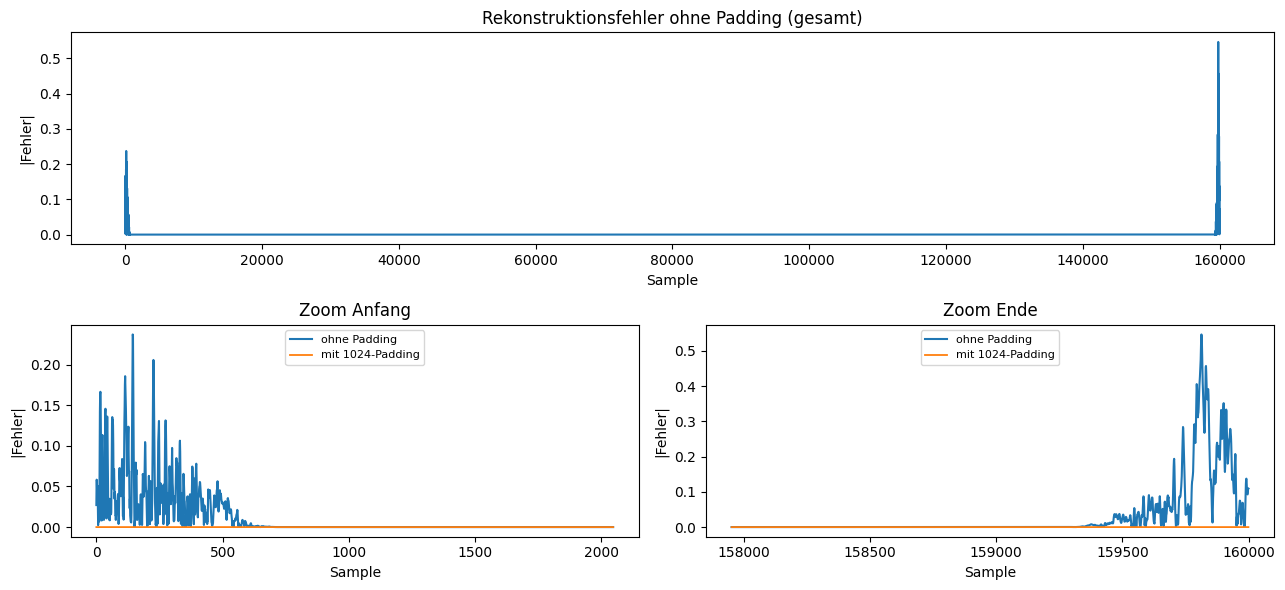

In [3]:
# Idee: vor der STFT um eine Fensterlänge zero-padden, nach der iSTFT wieder
# abschneiden. Die unvollständig überlappten Randframes liegen dann im Padding,
# das echte Signal wird auch am Rand vollständig rekonstruiert.
def round_trip_err(x, pad):
    xp = np.pad(x, (pad, pad)).astype(np.float32)
    y = istft(stft(xp)).numpy()
    y = y[pad:pad + len(x)]            # zugefügten Bereich wieder abschneiden
    return np.abs(y - x)

err = round_trip_err(wave, 0)                 # ohne Padding
err_pad = round_trip_err(wave, cfg.N_FFT)     # mit N_FFT-Padding
print("max |Fehler| ohne Padding (innen):", err[cfg.N_FFT:-cfg.N_FFT].max())
print("max |Fehler| mit Padding (gesamt):", err_pad.max())

zoom = 2 * cfg.N_FFT
n = len(wave)

fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 2)
ax_full = fig.add_subplot(gs[0, :])           # oben: gesamter Fehler (volle Breite)
ax_start = fig.add_subplot(gs[1, 0])          # unten links: Zoom Anfang
ax_end = fig.add_subplot(gs[1, 1])            # unten rechts: Zoom Ende

ax_full.plot(err, color="C0")
ax_full.set_title("Rekonstruktionsfehler ohne Padding (gesamt)")
ax_full.set_xlabel("Sample"); ax_full.set_ylabel("|Fehler|")

for ax, sl, x0, title in [(ax_start, slice(0, zoom), 0, "Zoom Anfang"),
                          (ax_end, slice(n - zoom, n), n - zoom, "Zoom Ende")]:
    xs = np.arange(x0, x0 + (sl.stop - sl.start))
    ax.plot(xs, err[sl], color="C0", label="ohne Padding")
    ax.plot(xs, err_pad[sl], color="C1", lw=1.3, label=f"mit {cfg.N_FFT}-Padding")
    ax.set_title(title); ax.set_xlabel("Sample"); ax.set_ylabel("|Fehler|")
    ax.legend(loc="upper center", fontsize=8)

plt.tight_layout(); plt.show()

## 2. Bandbegrenzung @ 8 kHz

Der Input entsteht durch Nullsetzen aller Bins ab dem Cutoff (Bin 256) — das HF-Band oberhalb der weißen Linie verschwindet.

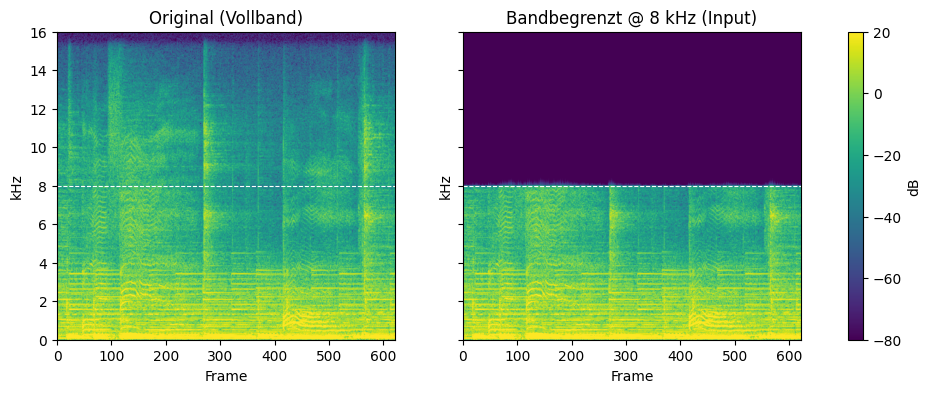

In [4]:
band = bandlimit(wave)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
show_spec(ax[0], stft(wave), "Original (Vollband)")
im = show_spec(ax[1], stft(band), "Bandbegrenzt @ 8 kHz (Input)")
fig.colorbar(im, ax=ax, label="dB"); plt.show()

## 3. Copy-Up (HF-Initialisierung)

Auf dem **komprimierten** Input-Spektrogramm wird das Band 4–8 kHz zweimal nach
oben gekachelt (→ 8–12 und 12–16 kHz) und am Crossover grob im Pegel angeglichen.
Das HF ist danach gefüllt, aber sichtbar „kopiert" (wiederholte Struktur) — die
bewusst primitive Baseline.

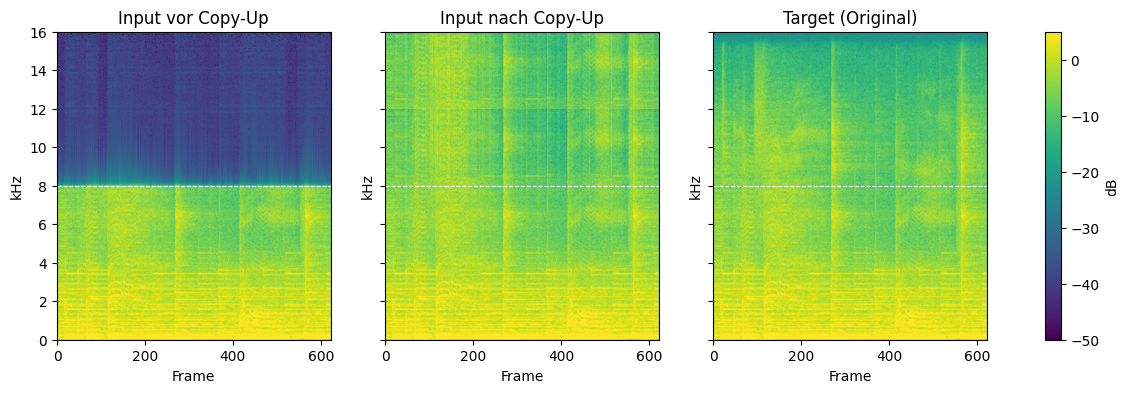

In [5]:
spec_band = drop_nyquist(compress(stft(band)))   # komprimiert, 512 Bins
spec_in = copy_up_hf(spec_band)                   # HF per Hochkopie gefüllt
spec_tg = drop_nyquist(compress(stft(wave)))      # Target (Original)

# dieselbe spectro_triple-Funktion wie im Baseline-Notebook (hier mit Spektrogrammen)
P.spectro_triple(spec_band, spec_in, spec_tg,
                 titles=("Input vor Copy-Up", "Input nach Copy-Up", "Target (Original)"),
                 vmin=-50, vmax=5)
plt.show()

### Copy-Up als Frequenzgang (ein Frame)

Derselbe Schritt aus einem anderen Blickwinkel: **ein einzelner Zeit-Frame** als
Frequenzgang statt als Spektrogramm. Man sieht direkt, dass „nach Copy-Up" oberhalb
des Cutoffs (8 kHz) das Quellband 4–8 kHz zweimal hochkopiert (Patch 1 → 8–12 kHz,
Patch 2 → 12–16 kHz), während „vor Copy-Up" dort leer ist. Der Energieabgleich
hebt/senkt die Patches so, dass am Crossover keine Stufe zur LF-Fortsetzung entsteht.

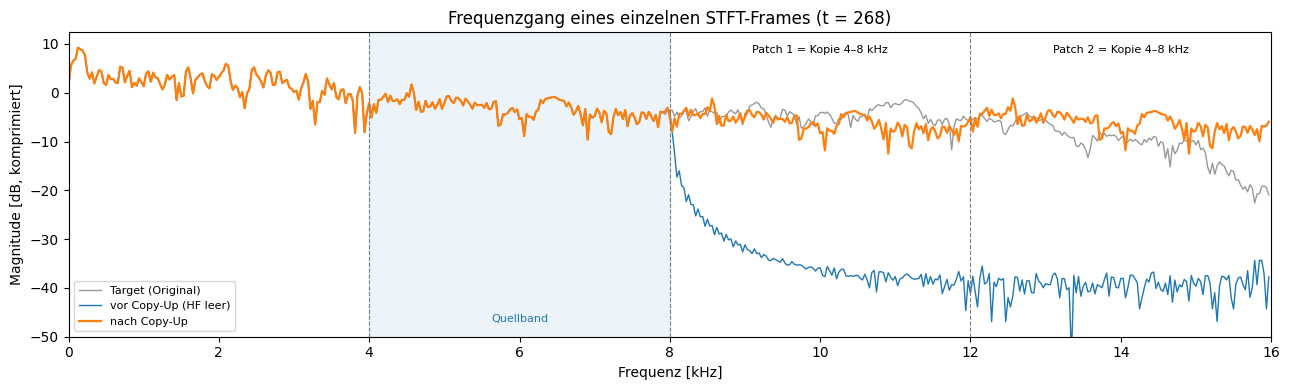

In [6]:
# Ein einzelner Zeit-Frame als Frequenzgang (statt Spektrogramm).
src_energy = np.abs(spec_band.numpy())[cfg.COPYUP_SRC_LO_BIN:cfg.CUTOFF_BIN].sum(axis=0)
t0 = 268 #85
freqs = np.arange(cfg.N_BINS_NET) * cfg.FREQ_RES / 1000    # Bin -> kHz

fig, ax = plt.subplots(figsize=(13, 4))
ax.axvspan(4, 8, color="C0", alpha=0.08)                   # Quellband 4–8 kHz hervorheben
ax.plot(freqs, db(spec_tg)[:, t0], color="0.6", lw=1.0, label="Target (Original)")
ax.plot(freqs, db(spec_band)[:, t0], color="C0", lw=1.0, label="vor Copy-Up (HF leer)")
ax.plot(freqs, db(spec_in)[:, t0], color="C1", lw=1.6, label="nach Copy-Up")

for f in (4, 8, 12):                                       # Quellband- und Patch-Grenzen
    ax.axvline(f, color="grey", ls="--", lw=0.8)
trans = ax.get_xaxis_transform()                           # x in Daten, y in Achsenanteil
ax.text(6, 0.05, "Quellband", transform=trans, ha="center", fontsize=8, color="C0")
ax.text(10, 0.96, "Patch 1 = Kopie 4–8 kHz", transform=trans, ha="center", va="top", fontsize=8)
ax.text(14, 0.96, "Patch 2 = Kopie 4–8 kHz", transform=trans, ha="center", va="top", fontsize=8)

ax.set_xlim(0, cfg.SR / 2 / 1000)
ax.set_ylim(bottom=-50)                                    # starke HF-Ausreißer ausblenden
ax.set_xlabel("Frequenz [kHz]"); ax.set_ylabel("Magnitude [dB, komprimiert]")
ax.set_title(f"Frequenzgang eines einzelnen STFT-Frames (t = {t0})")
ax.legend(loc="lower left", fontsize=8); plt.tight_layout(); plt.show()

### Crossover-Zoom

Detail um den Cutoff (8 kHz): die „Naht", an der das kopierte HF ansetzt.

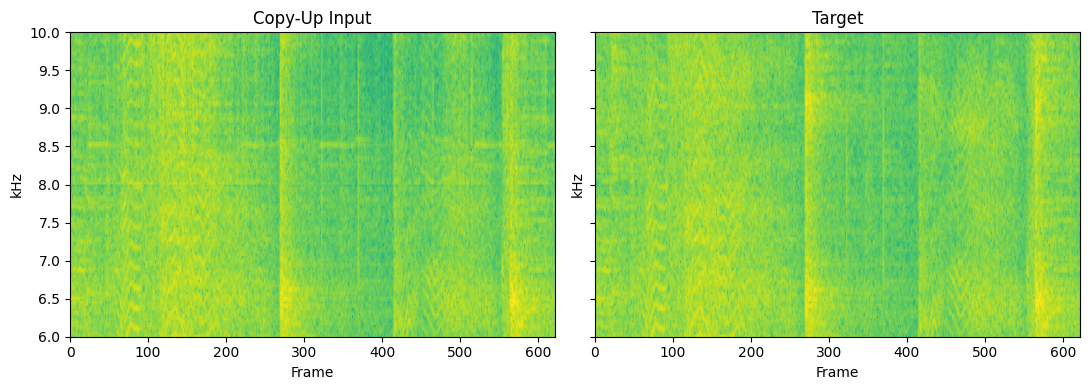

In [7]:
# dieselbe crossover_zoom-Funktion wie im Baseline-Notebook (ohne Cutoff-Linie,
# damit die Naht sichtbar bleibt)
P.crossover_zoom(spec_in, spec_tg, titles=("Copy-Up Input", "Target"), vmin=-50, vmax=5)
plt.show()

## Fazit

Die DSP-Kette steht und ist getestet (STFT-Round-Trip, Kompression, Bandbegrenzung,
Copy-Up, tf.data-Pipeline). Copy-Up füllt das HF sichtbar, aber als grobe Hochkopie —
das ist der **naive Anker**. Sein Kontrast macht später die gelernten Stufen
(komplexe Regression → GAN) sichtbar: von „kopiert/verwaschen" zu „scharf".